### Previously, we fill the null-values with the median. Now, we do different approach. Just drop the missing values

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Import data
df_raw = pd.read_csv('../data/covid_19.csv')

In [16]:
# Data observation
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB


In [17]:
# Check for missing values
df_raw.isnull().sum()

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

In [18]:
# Removes the row
df_raw = df_raw.dropna()

In [19]:
# Check again
df_raw.isnull().sum()

country       0
continent     0
population    0
day           0
time          0
Cases         0
Recovered     0
Deaths        0
Tests         0
dtype: int64

In [20]:
# To make the column's name consisten, we convert to lower case
df_raw.columns = df_raw.columns.str.lower()

In [21]:
# We also change the data type for day and time
df_raw['day'] = pd.to_datetime(df_raw['day'])
df_raw['time'] =  pd.to_datetime(df_raw['time'])

In [22]:
df_raw.info()

<class 'pandas.DataFrame'>
Index: 169 entries, 2 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   country     169 non-null    str                
 1   continent   169 non-null    str                
 2   population  169 non-null    float64            
 3   day         169 non-null    datetime64[us]     
 4   time        169 non-null    datetime64[us, UTC]
 5   cases       169 non-null    int64              
 6   recovered   169 non-null    float64            
 7   deaths      169 non-null    float64            
 8   tests       169 non-null    float64            
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 13.2 KB


In [23]:
# Perform quick statistical overview
stats_col = ['cases', 'recovered', 'deaths', 'tests']
df_raw[stats_col].describe()

,cases,recovered,deaths,tests
count,1.690000e+02,1.690000e+02,1.690000e+02,1.690000e+02
mean,3.358564e+06,3.288112e+06,3.437705e+04,3.114130e+07
std,1.082718e+07,1.062387e+07,1.199160e+05,1.129389e+08
min,1.403000e+03,4.380000e+02,1.000000e+00,7.850000e+03
25%,3.613800e+04,3.233200e+04,3.160000e+02,4.004660e+05
50%,2.720100e+05,2.588880e+05,3.165000e+03,2.525756e+06
75%,1.734582e+06,1.724921e+06,1.805700e+04,1.346373e+07
max,1.118201e+08,1.098144e+08,1.219487e+06,1.186852e+09


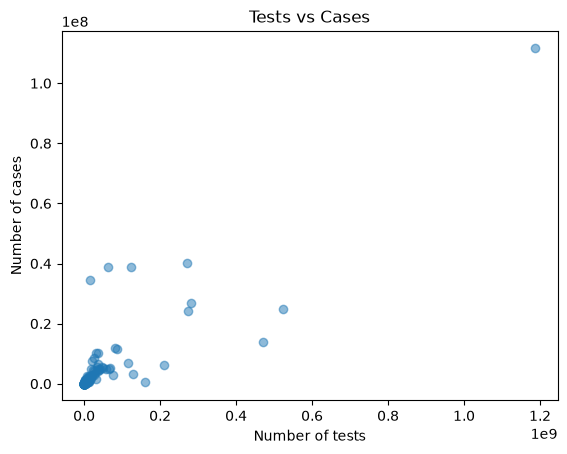

In [24]:
# Observe the Cases vs Tests using Scatter Plot
plt.scatter(df_raw['tests'], df_raw['cases'], alpha=0.5)
plt.xlabel('Number of tests')
plt.ylabel('Number of cases')
plt.title('Tests vs Cases')
plt.show()

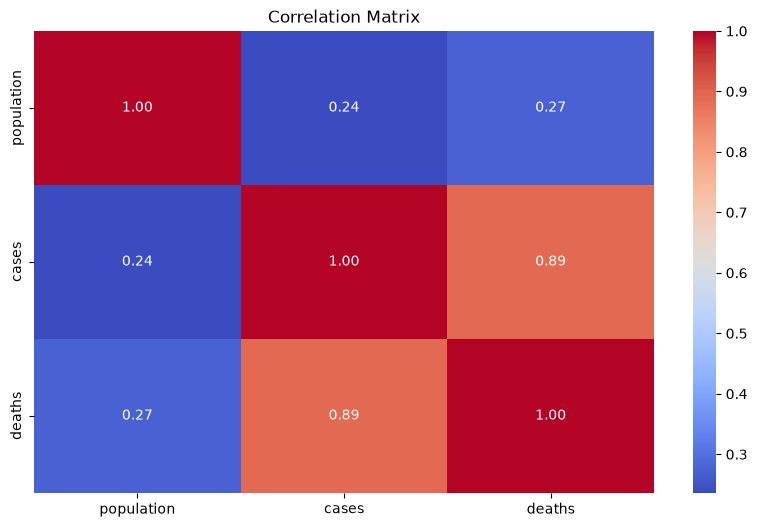

In [25]:
# Create correlation between population, deaths, and cases
corr_mat = df_raw[['population', 'cases', 'deaths']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

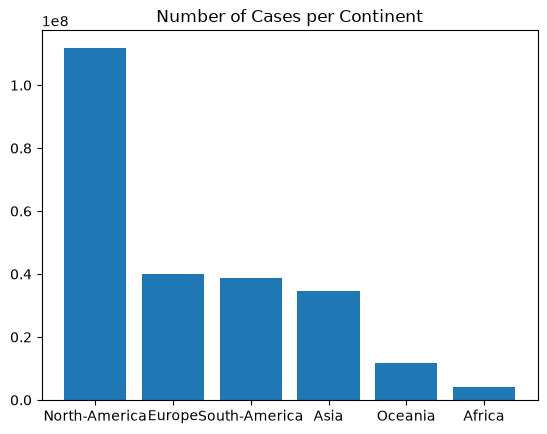

In [34]:
# Number of cases per continent
sorted_continent = df_raw.sort_values('cases', ascending=False)
bar = plt.bar(
    sorted_continent['continent'],
    sorted_continent['cases'],
)
plt.title('Number of Cases per Continent')
plt.show()

In [ ]:
# Feature engineering
# Add recovery rate column - number of recovery per total cases
df_raw['recovery_rate'] = df_raw['recovered']/df_raw['cases']*100

2      98.075552
7      75.313231
9      70.944380
14     98.323773
15     23.064072
         ...    
232    99.814432
233    98.700869
234    99.731501
235    89.575959
237    97.333268
Name: recovery_rate, Length: 169, dtype: float64

[Text(0, 0, '93.03%'),
 Text(0, 0, '93.02%'),
 Text(0, 0, '98.60%'),
 Text(0, 0, '91.13%'),
 Text(0, 0, '82.46%'),
 Text(0, 0, '89.30%')]

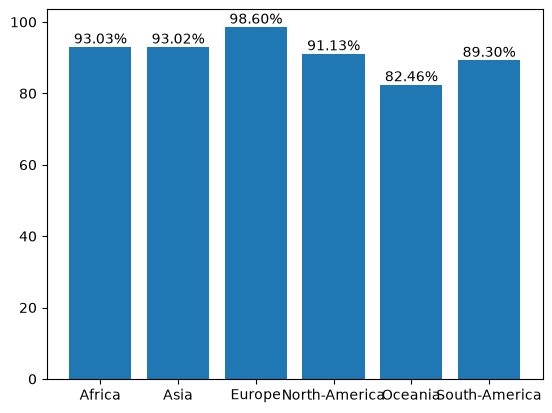

In [44]:
# Average rate per continent
average_recovery_rate_per_continent = df_raw.groupby('continent')['recovery_rate'].mean()
bar = plt.bar(
    average_recovery_rate_per_continent.index,
    average_recovery_rate_per_continent.values
)
plt.bar_label(
    bar,
    fmt="%.2f%%"
)

In [50]:
# Metric analysis - Cases per Capita
df_raw['cases_per_capita'] = df_raw['cases']/df_raw['population']*1000
highest_case_per_capita = df_raw.loc[df_raw.groupby('continent')['cases_per_capita'].idxmax()]
lowest_case_per_capita = df_raw.loc[df_raw.groupby('continent')['cases_per_capita'].idxmin()]
highest_case_per_capita['country']
lowest_case_per_capita['country']

17                Niger
7                 China
117             Belarus
80                Haiti
74     Papua-New-Guinea
118           Venezuela
Name: country, dtype: str